In [1]:
#####################################
### Import the relevant libraries ###
#####################################

import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import time

To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


***
# **DATA**

In [2]:
#########################################
### Load the moral regression dataset ###
#########################################

# Each row is one timestep of a rescue episode: the agent's accumulated risk R and the
# room it has reached (5 inputs), followed by the regression target `effort` in [0, 1]
features = ['R', 'p_alive', 'n_estimated', 'urgency', 'is_closed']

def load_split(split):
    data = np.loadtxt(f'data/{split}.csv', delimiter=',', skiprows=1, dtype='float32')
    return data[:, :5], data[:, 5]

X_train, y_train = load_split('train')
X_val, y_val = load_split('val')
X_test, y_test = load_split('test')

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)

(14000, 5)
(3000, 5)
(3000, 5)
(14000,)


In [3]:
###############################
### Visualise some examples ###
###############################

def display_some_examples(examples, targets, n_examples):
    print(f"{'R':>6} {'p_alive':>8} {'n_estimated':>12} {'urgency':>8} {'is_closed':>10} {'effort':>8}")

    for i in range(n_examples):
        idx = np.random.randint(0, examples.shape[0] - 1)
        R, p_alive, n_estimated, urgency, is_closed = examples[idx]
        effort = targets[idx]

        print(f'{R:6.3f} {p_alive:8.3f} {n_estimated:12.3f} {urgency:8.0f} {is_closed:10.0f} {effort:8.3f}')

display_some_examples(X_train, y_train, n_examples=15)

     R  p_alive  n_estimated  urgency  is_closed   effort
 0.233    1.000        2.391        3          0    0.083
 0.088    0.320        2.063        5          1    0.000
 0.000    1.000        3.072        1          0    0.000
 0.392    0.322        3.147        5          1    0.002
 0.000    1.000        2.716        5          0    0.429
 0.301    1.000        4.176        3          0    0.263
 0.609    0.031        3.696        5          1    0.000
 0.202    1.000        3.262        1          0    0.000
 0.380    1.000        1.152        5          0    0.024
 0.554    1.000        3.097        1          0    0.000
 0.450    0.250        1.325        3          1    0.000
 0.000    0.236        1.132        5          1    0.000
 0.556    0.855        2.183        1          1    0.000
 0.095    0.047        4.693        1          1    0.000
 0.553    0.729        1.899        3          1    0.000


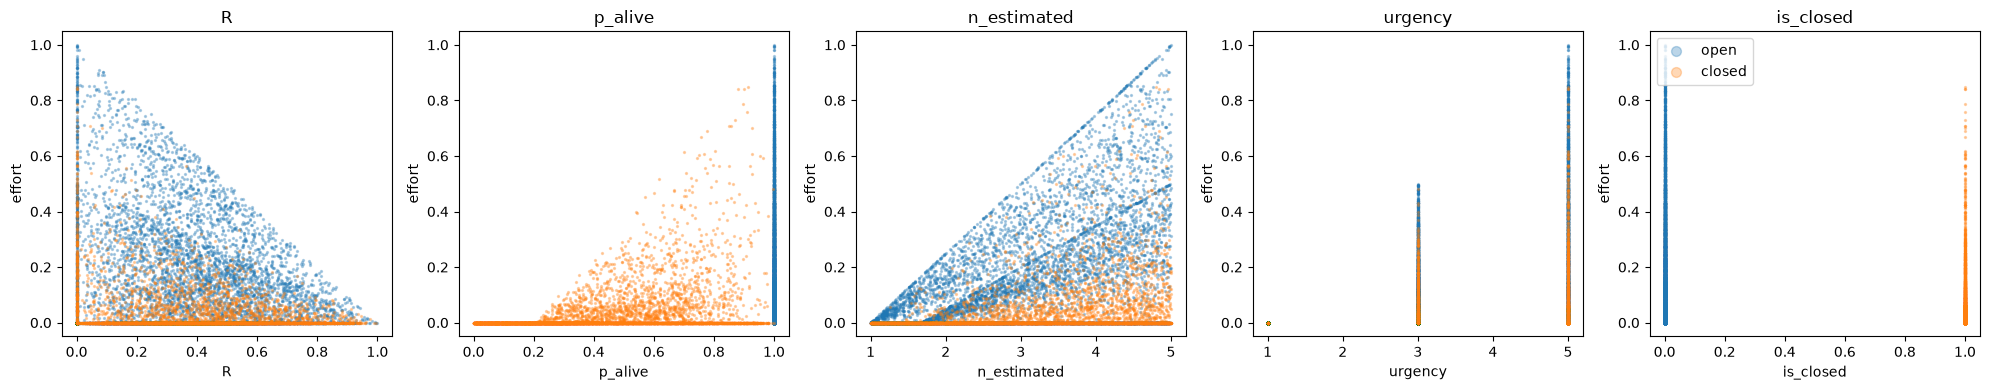

In [4]:
###############################
### Visualise some features ###
###############################

def plot_features_vs_effort(examples, targets):
    closed = examples[:, 4] == 1

    plt.figure(figsize=(20, 4))

    for i, name in enumerate(features):
        plt.subplot(1, 5, i + 1)

        # Plot the feature values on the x-axis and the effort on the y-axis
        plt.scatter(examples[~closed, i], targets[~closed], alpha=0.3, s=2, label='open')
        plt.scatter(examples[closed, i], targets[closed], alpha=0.3, s=2, label='closed')

        plt.title(name)
        plt.xlabel(name)
        plt.ylabel('effort')

    plt.legend(loc='upper left', markerscale=5)
    plt.tight_layout()
    plt.show()

plot_features_vs_effort(X_train, y_train)

***
# **BASE TRAINING**

In [5]:
##########################
### Set some variables ###
##########################

input_size = 5
batch_size = 64
epochs = 50
epsilon_R = 0.05  # R (risk) may move by +/- 0.05
epsilon_p = 0.05  # p_alive may move by +/- 0.05
alpha = 0.01      # PGD step size (R and p_alive share the same [0, 1] scale)
num_iter = 10

In [6]:
############################
### Pre-process the data ###
############################

# The inputs are kept raw (not normalised) so that epsilon_R and epsilon_p stay in R and p_alive units.
# The target is reshaped to (n, 1) to match the single output of the model.

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train[:, None]))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val[:, None]))

train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)
val_dataset = val_dataset.batch(batch_size)

In [7]:
########################
### Define the model ###
########################

def get_model(input_size, seed=42, summary=True):
    initializer = tf.keras.initializers.GlorotUniform(seed=seed)
    model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_size,), name='input_features'),
            tf.keras.layers.Dense(64, activation='relu', kernel_initializer=initializer, name='dense_1'),
            tf.keras.layers.Dense(64, activation='relu', kernel_initializer=initializer, name='dense_2'),
            tf.keras.layers.Dense(1, activation='linear', kernel_initializer=initializer, name='output_layer')
        ])
    if summary:
        print(model.summary())
    return model

In [8]:
##########################
### Train a base model ###
##########################

optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.MeanSquaredError()
mae_fn = tf.keras.metrics.MeanAbsoluteError()

model_base = get_model(input_size)
model_base.compile(optimizer=optimizer, loss=loss_fn, metrics=[mae_fn])
model_base.fit(train_dataset, epochs=epochs, validation_data=val_dataset, verbose=2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50


/home/melon501/source/JC-DAIR/moral-regression/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


219/219 - 1s - 3ms/step - loss: 0.0124 - mean_absolute_error: 0.0667 - val_loss: 0.0022 - val_mean_absolute_error: 0.0296
Epoch 2/50
219/219 - 0s - 756us/step - loss: 0.0016 - mean_absolute_error: 0.0247 - val_loss: 0.0011 - val_mean_absolute_error: 0.0195
Epoch 3/50
219/219 - 0s - 774us/step - loss: 8.9981e-04 - mean_absolute_error: 0.0184 - val_loss: 7.0295e-04 - val_mean_absolute_error: 0.0163
Epoch 4/50
219/219 - 0s - 752us/step - loss: 6.6454e-04 - mean_absolute_error: 0.0164 - val_loss: 4.9597e-04 - val_mean_absolute_error: 0.0129
Epoch 5/50
219/219 - 0s - 751us/step - loss: 5.0294e-04 - mean_absolute_error: 0.0144 - val_loss: 3.7746e-04 - val_mean_absolute_error: 0.0115
Epoch 6/50
219/219 - 0s - 793us/step - loss: 3.7960e-04 - mean_absolute_error: 0.0125 - val_loss: 2.9439e-04 - val_mean_absolute_error: 0.0110
Epoch 7/50
219/219 - 0s - 721us/step - loss: 3.7870e-04 - mean_absolute_error: 0.0134 - val_loss: 6.3516e-04 - val_mean_absolute_error: 0.0217
Epoch 8/50
219/219 - 0s - 71

In [9]:
#####################################
### Define the regression metrics ###
#####################################

def print_metrics(model, x, y):
    # Get the predicted efforts
    y_pred = model.predict(x, verbose=0)[:, 0]

    # Calculate MSE, MAE and R2
    mse = np.mean((y_pred - y) ** 2)
    mae = np.mean(np.abs(y_pred - y))
    r2 = 1 - np.sum((y_pred - y) ** 2) / np.sum((y - y.mean()) ** 2)

    print(f'MSE: {mse:.6f}')
    print(f'MAE: {mae:.6f}')
    print(f'R2: {r2:.4f}')

    # Plot predicted vs true effort
    plt.figure(figsize=(6, 5))
    plt.scatter(y, y_pred, alpha=0.3, s=2)
    lims = [y.min(), y.max()]
    plt.plot(lims, lims, 'k--', lw=1)  # Perfect prediction
    plt.xlabel('True effort')
    plt.ylabel('Predicted effort')
    plt.title('Predicted vs true effort')
    plt.show()

MSE: 0.000037
MAE: 0.004488
R2: 0.9985


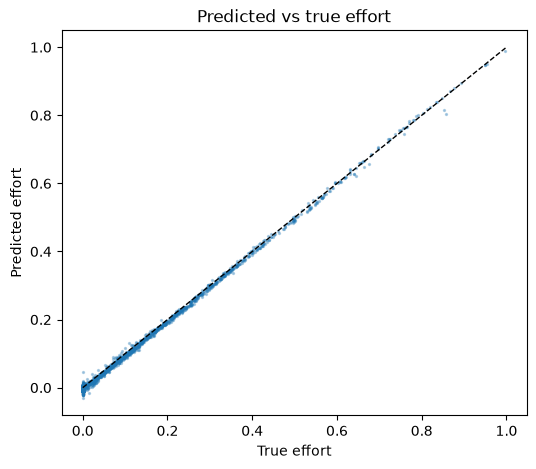

In [10]:
####################################
### Calculate regression metrics ###
####################################

print_metrics(model_base, X_test, y_test)

### PGD for a regression model

As in classification, PGD perturbs the input to **maximise the loss** w.r.t. the true target,
here the squared error on the effort.

Two inputs may be perturbed, each with its own epsilon:

* `R`, the agent's accumulated risk, in **every** room, within +/- epsilon_R and clipped to [0, 1].
* `p_alive` of **closed** rooms only, within +/- epsilon_p and clipped to [0, 1]. Open rooms have
  been seen inside (`p_alive = 1`).

`n_estimated`, `urgency` and `is_closed` stay fixed. Open rooms can therefore only be attacked
through `R`, while closed rooms can be attacked through both.

In [11]:
######################################
### Define the PGD attack function ###
######################################

def pgd_attack(model, x, y, epsilon_R, epsilon_p, alpha, num_iter):
    """Perform a masked PGD attack on a batch of rooms.

    Args:
        model: Trained Keras model.
        x: Input states (batch), columns [R, p_alive, n_estimated, urgency, is_closed].
        y: True efforts (batch), shape (n, 1).
        epsilon_R: Maximum perturbation of R.
        epsilon_p: Maximum perturbation of p_alive (closed rooms only).
        alpha: Step size for each iteration.
        num_iter: Number of PGD iterations.

    Returns:
        Adversarial examples.
    """
    x = tf.convert_to_tensor(x)

    # Per-row epsilon: R (column 0) in every room, p_alive (column 1) only when closed (column 4 == 1)
    epsilon = tf.constant([epsilon_R, 0.0, 0.0, 0.0, 0.0]) + tf.constant([0.0, epsilon_p, 0.0, 0.0, 0.0]) * x[:, 4:5]
    mask = tf.cast(epsilon > 0, x.dtype)  # 1 where the input may change

    # Make a copy of the input to avoid modifying the original data
    x_adv = tf.identity(x)

    # Iterate PGD for num_iter steps
    for i in range(num_iter):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)  # Watch x_adv for gradient computation
            predictions = model(x_adv)  # Forward pass
            loss = tf.square(predictions - y)  # Squared error w.r.t. true effort

        # Compute the gradients of the loss w.r.t. the input
        gradients = tape.gradient(loss, x_adv)

        # Perform gradient ascent step, only on the perturbable features
        perturbations = tf.sign(gradients) * mask  # Use the sign of the gradients (FGSM-like step)
        x_adv = x_adv + alpha * perturbations  # Update the adversarial example

        # Project the adversarial example to ensure it's within epsilon-ball of the original room
        x_adv = tf.clip_by_value(x_adv, x - epsilon, x + epsilon)

        # Ensure R and p_alive stay within the valid range [0, 1]
        x_adv = tf.clip_by_value(x_adv, 0.0, 1.0) * mask + x * (1 - mask)

    return x_adv

In [12]:
###########################################################################
### Define the function to visualize the original and adversarial rooms ###
###########################################################################

def original_vs_adversarial_rooms(model, x_og, y_og, x_adv, epsilon_R, epsilon_p):
    pred_og = model.predict(x_og, verbose=0)[:, 0]
    pred_adv = model.predict(x_adv, verbose=0)[:, 0]

    # The 10 closed rooms where the attack increased the error the most
    # (closed rooms can move in both R and p_alive, so the ball is a 2D box)
    error_increase = np.abs(pred_adv - y_og) - np.abs(pred_og - y_og)
    error_increase[x_og[:, 4] == 0] = -np.inf
    worst = np.argsort(error_increase)[::-1][:10]

    plt.figure(figsize=(18, 7))

    # Show the model's effort over the whole epsilon-box of R and p_alive
    for count, i in enumerate(worst):
        R, p = x_og[i, 0], x_og[i, 1]
        R_grid = np.linspace(max(R - epsilon_R, 0), min(R + epsilon_R, 1), 40)
        p_grid = np.linspace(max(p - epsilon_p, 0), min(p + epsilon_p, 1), 40)
        RR, PP = np.meshgrid(R_grid, p_grid)
        x_grid = np.repeat(x_og[i:i + 1], RR.size, axis=0)
        x_grid[:, 0] = RR.ravel()
        x_grid[:, 1] = PP.ravel()
        effort_grid = model.predict(x_grid, verbose=0)[:, 0].reshape(RR.shape)

        plt.subplot(2, 5, count + 1)
        plt.imshow(effort_grid, origin='lower', aspect='auto', cmap='viridis',
                   extent=[R_grid[0], R_grid[-1], p_grid[0], p_grid[-1]])
        plt.colorbar(label='predicted effort')
        plt.scatter([R], [p], color='tab:green', edgecolor='w', zorder=3, clip_on=False, label='original')
        plt.scatter([x_adv[i, 0]], [x_adv[i, 1]], color='tab:red', edgecolor='w', s=50, zorder=3, clip_on=False, label='adversarial')
        plt.title(f'n={x_og[i, 2]:.1f}, urgency={x_og[i, 3]:.0f}, true={y_og[i]:.2f}\n'
                  f'pred {pred_og[i]:.2f} -> {pred_adv[i]:.2f}', fontsize=9)
        plt.xlabel('R')
        plt.ylabel('p_alive')

    plt.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

MSE on original rooms: 0.000037
MSE on adversarial examples: 0.000431
  open rooms (R only): 0.000023 -> 0.000409
  closed rooms (R and p_alive): 0.000051 -> 0.000454
Largest change in predicted effort: 0.077911


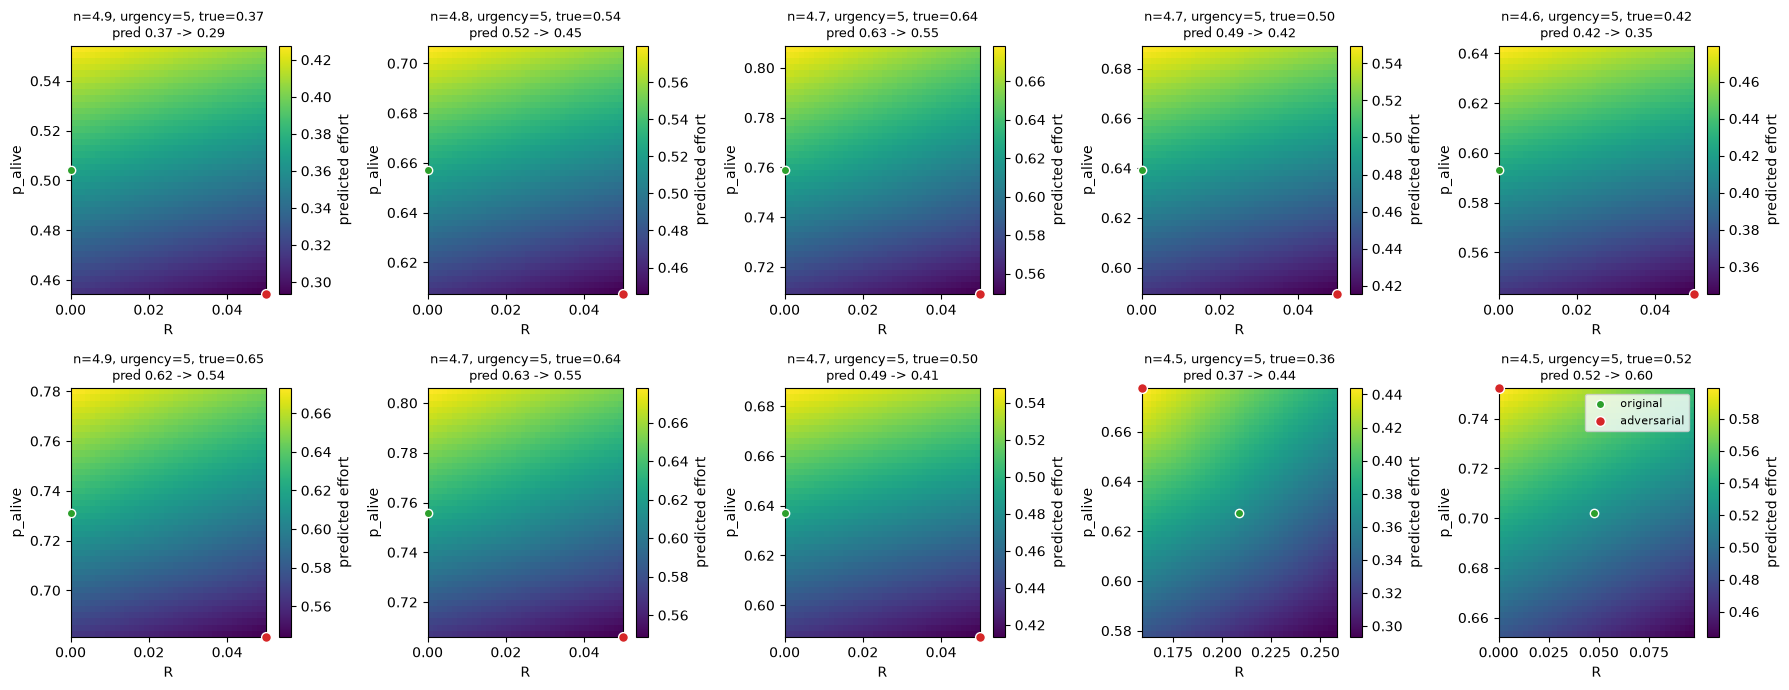

In [13]:
###################################################################################
### Attack the model using PGD and visualize the original and adversarial rooms ###
###################################################################################

# Test the PGD attack on all rooms (open rooms can still be attacked through R)
x_test_sample = X_test
y_test_sample = y_test
closed = X_test[:, 4] == 1

# Generate adversarial examples
x_test_adv = pgd_attack(model_base, x_test_sample, y_test_sample[:, None], epsilon_R=epsilon_R, epsilon_p=epsilon_p, alpha=alpha, num_iter=num_iter).numpy()

# Evaluate the model on the original and adversarial examples
y_pred_og = model_base.predict(x_test_sample, verbose=0)[:, 0]
y_pred_adv = model_base.predict(x_test_adv, verbose=0)[:, 0]
sq_err_og = (y_pred_og - y_test_sample) ** 2
sq_err_adv = (y_pred_adv - y_test_sample) ** 2
max_change = np.max(np.abs(y_pred_adv - y_pred_og))

print(f'MSE on original rooms: {sq_err_og.mean():.6f}')
print(f'MSE on adversarial examples: {sq_err_adv.mean():.6f}')
print(f'  open rooms (R only): {sq_err_og[~closed].mean():.6f} -> {sq_err_adv[~closed].mean():.6f}')
print(f'  closed rooms (R and p_alive): {sq_err_og[closed].mean():.6f} -> {sq_err_adv[closed].mean():.6f}')
print(f'Largest change in predicted effort: {max_change:.6f}')
original_vs_adversarial_rooms(model_base, x_test_sample, y_test_sample, x_test_adv, epsilon_R, epsilon_p)

***
# **ADVERSARIAL TRAINING**

In [14]:
################################################
### Define the adversarial training function ###
################################################

def adversarial_training(model, train_dataset, val_dataset, optimizer, loss_fn, epsilon_R, epsilon_p, alpha, num_iter, epochs, verbose=True):
    """
    Performs adversarial training with PGD adversarial examples.

    Args:
    model: The model to train.
    train_dataset: A TensorFlow dataset for training.
    val_dataset: A TensorFlow dataset for validation.
    optimizer: The optimizer for model training.
    loss_fn: Loss function to use.
    epsilon_R: Maximum perturbation of R for PGD.
    epsilon_p: Maximum perturbation of p_alive for PGD (closed rooms only).
    alpha: Step size for PGD.
    num_iter: Number of PGD iterations for generating adversarial examples.
    epochs: Number of training epochs.
    verbose: Print the loss and validation MSE after every epoch.

    Returns:
    model: The trained model.
    """

    @tf.function  # Compile the step into a graph, otherwise PGD makes training slow
    def train_step(x_batch, y_batch):
        # Generate adversarial examples using PGD
        x_adv_batch = pgd_attack(model, x_batch, y_batch, epsilon_R=epsilon_R, epsilon_p=epsilon_p, alpha=alpha, num_iter=num_iter)

        with tf.GradientTape() as tape:
            # Combine original and adversarial examples for training; the adversarial
            # examples keep the original effort as their target
            combined_x = tf.concat([x_batch, x_adv_batch], axis=0)
            combined_y = tf.concat([y_batch, y_batch], axis=0)

            # Forward pass
            predictions = model(combined_x, training=True)

            # Compute the loss
            loss = loss_fn(combined_y, predictions)

        # Backpropagation
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    for epoch in range(epochs):
        start_time = time.time()  # Record start time for the epoch

        # Training loop over batches
        for step, (x_batch, y_batch) in enumerate(train_dataset):
            loss = train_step(x_batch, y_batch)

        # Evaluate on the validation dataset
        val_pred = model.predict(val_dataset, verbose=0)[:, 0]
        val_mse = np.mean((val_pred - y_val) ** 2)

        if verbose:
            print(f"Epoch {epoch + 1}/{epochs} -|- Train loss: {loss.numpy():.6f} -|- Val MSE: {val_mse:.6f} -|- Time: {(time.time() - start_time):.2f}s")

    return model

In [15]:
##################################
### Train an adversarial model ###
##################################

optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.MeanSquaredError()

model_adv = get_model(input_size)
model_adv = adversarial_training(model_adv, train_dataset, val_dataset, optimizer, loss_fn, epsilon_R=epsilon_R, epsilon_p=epsilon_p, alpha=alpha, num_iter=num_iter, epochs=epochs)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50 -|- Train loss: 0.003638 -|- Val MSE: 0.002587 -|- Time: 1.36s
Epoch 2/50 -|- Train loss: 0.000700 -|- Val MSE: 0.000984 -|- Time: 0.23s
Epoch 3/50 -|- Train loss: 0.000668 -|- Val MSE: 0.000663 -|- Time: 0.21s
Epoch 4/50 -|- Train loss: 0.000623 -|- Val MSE: 0.000493 -|- Time: 0.21s
Epoch 5/50 -|- Train loss: 0.000744 -|- Val MSE: 0.000378 -|- Time: 0.26s
Epoch 6/50 -|- Train loss: 0.001315 -|- Val MSE: 0.000393 -|- Time: 0.26s
Epoch 7/50 -|- Train loss: 0.000737 -|- Val MSE: 0.000880 -|- Time: 0.21s
Epoch 8/50 -|- Train loss: 0.000878 -|- Val MSE: 0.000249 -|- Time: 0.22s
Epoch 9/50 -|- Train loss: 0.000352 -|- Val MSE: 0.000191 -|- Time: 0.23s
Epoch 10/50 -|- Train loss: 0.000559 -|- Val MSE: 0.000176 -|- Time: 0.24s
Epoch 11/50 -|- Train loss: 0.000485 -|- Val MSE: 0.000225 -|- Time: 0.24s
Epoch 12/50 -|- Train loss: 0.000553 -|- Val MSE: 0.000261 -|- Time: 0.24s
Epoch 13/50 -|- Train loss: 0.000290 -|- Val MSE: 0.000116 -|- Time: 0.25s
Epoch 14/50 -|- Train loss: 0

MSE: 0.000112
MAE: 0.007959
R2: 0.9954


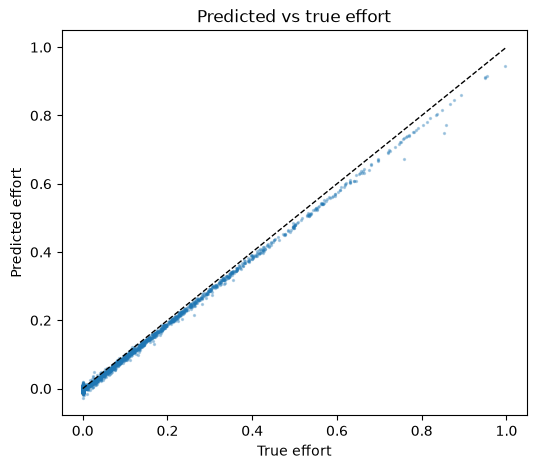

In [16]:
####################################
### Calculate regression metrics ###
####################################

print_metrics(model_adv, X_test, y_test)

MSE on original rooms: 0.000112
MSE on adversarial examples: 0.000640
  open rooms (R only): 0.000144 -> 0.000742
  closed rooms (R and p_alive): 0.000080 -> 0.000536
Largest change in predicted effort: 0.082877


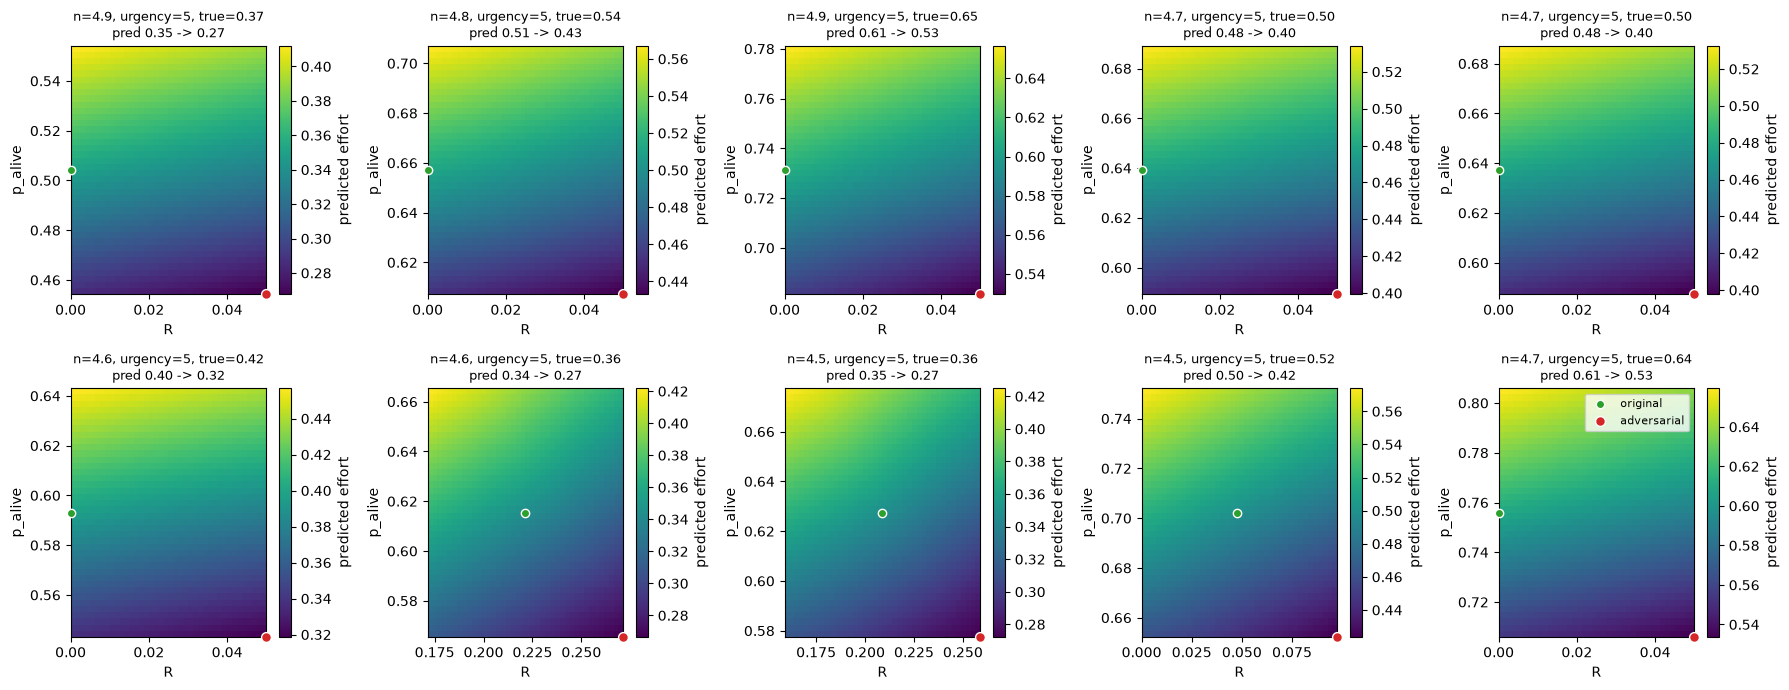

In [17]:
###################################################################################
### Attack the model using PGD and visualize the original and adversarial rooms ###
###################################################################################

# Test the PGD attack on all rooms (open rooms can still be attacked through R)
x_test_sample_ADV = X_test
y_test_sample_ADV = y_test
closed_ADV = X_test[:, 4] == 1

# Generate adversarial examples
x_test_adv_ADV = pgd_attack(model_adv, x_test_sample_ADV, y_test_sample_ADV[:, None], epsilon_R=epsilon_R, epsilon_p=epsilon_p, alpha=alpha, num_iter=num_iter).numpy()

# Evaluate the model on the original and adversarial examples
y_pred_og_ADV = model_adv.predict(x_test_sample_ADV, verbose=0)[:, 0]
y_pred_adv_ADV = model_adv.predict(x_test_adv_ADV, verbose=0)[:, 0]
sq_err_og_ADV = (y_pred_og_ADV - y_test_sample_ADV) ** 2
sq_err_adv_ADV = (y_pred_adv_ADV - y_test_sample_ADV) ** 2
max_change_ADV = np.max(np.abs(y_pred_adv_ADV - y_pred_og_ADV))

print(f'MSE on original rooms: {sq_err_og_ADV.mean():.6f}')
print(f'MSE on adversarial examples: {sq_err_adv_ADV.mean():.6f}')
print(f'  open rooms (R only): {sq_err_og_ADV[~closed_ADV].mean():.6f} -> {sq_err_adv_ADV[~closed_ADV].mean():.6f}')
print(f'  closed rooms (R and p_alive): {sq_err_og_ADV[closed_ADV].mean():.6f} -> {sq_err_adv_ADV[closed_ADV].mean():.6f}')
print(f'Largest change in predicted effort: {max_change_ADV:.6f}')
original_vs_adversarial_rooms(model_adv, x_test_sample_ADV, y_test_sample_ADV, x_test_adv_ADV, epsilon_R, epsilon_p)

***
# **EPSILON AND SEED STUDY**

A single run is noisy: the base and adversarial model swap places between runs. Here both are
trained for several seeds and attacked at several epsilons (the same epsilon for `R` and `p_alive`),
and the results are averaged over seeds. Each adversarial model is trained at the epsilon it is
attacked with, and the PGD step size scales with epsilon (`alpha = 2.5 * epsilon / num_iter`).

Three errors are reported:

* **Clean MSE**: accuracy on the unperturbed test set.
* **Adversarial MSE vs original target**: the error PGD maximises, comparing f(x') with the effort at
  the *original* input x. This is the MNIST view: the label should not change inside the ball.
* **Adversarial MSE vs true target**: comparing f(x') with the controller's effort at the *perturbed*
  input x'. The controller is known (`compute_effort` in `simulation.py`), so we can ask whether the
  network is still correct at x', rather than whether it stayed constant.

The full study trains `len(seeds) * (1 + len(epsilons))` models and takes a few minutes.

In [18]:
###############################
### Set the study variables ###
###############################

epsilons = [0.01, 0.02, 0.05, 0.1]  # used for both epsilon_R and epsilon_p
seeds = [0, 1, 2, 3, 4]

In [19]:
#############################################
### Define the attack evaluation function ###
#############################################

from simulation import compute_effort

# The controller that generated the labels, applied row by row
true_effort = np.vectorize(compute_effort)

def attack_report(model, epsilon):
    x_adv = pgd_attack(model, X_test, y_test[:, None], epsilon_R=epsilon, epsilon_p=epsilon,
                       alpha=2.5 * epsilon / num_iter, num_iter=num_iter).numpy()

    pred = model.predict(X_test, verbose=0)[:, 0]
    pred_adv = model.predict(x_adv, verbose=0)[:, 0]

    # Effort the controller would commit at the perturbed input (columns: R, p_alive, n_estimated, urgency)
    y_adv_true = true_effort(x_adv[:, 1], x_adv[:, 2], x_adv[:, 3], x_adv[:, 0])

    return {
        'clean': np.mean((pred - y_test) ** 2),
        'adv_original': np.mean((pred_adv - y_test) ** 2),
        'adv_true': np.mean((pred_adv - y_adv_true) ** 2),
    }

In [20]:
####################################################################
### Train base and adversarial models for every seed and epsilon ###
####################################################################

results = {'base': {e: [] for e in epsilons}, 'adv': {e: [] for e in epsilons}}

for seed in seeds:
    start_time = time.time()

    # Fix the initialisation and the shuffling for this seed
    tf.keras.utils.set_random_seed(seed)
    seed_train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train[:, None]))
    seed_train_dataset = seed_train_dataset.shuffle(buffer_size=1024, seed=seed).batch(batch_size)

    # One base model per seed, attacked at every epsilon
    model = get_model(input_size, seed=seed, summary=False)
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.MeanSquaredError())
    model.fit(seed_train_dataset, epochs=epochs, verbose=0)
    for e in epsilons:
        results['base'][e].append(attack_report(model, e))

    # One adversarial model per seed and epsilon, attacked at the epsilon it was trained with
    for e in epsilons:
        model = get_model(input_size, seed=seed, summary=False)
        model = adversarial_training(model, seed_train_dataset, val_dataset, tf.keras.optimizers.Adam(),
                                     tf.keras.losses.MeanSquaredError(), epsilon_R=e, epsilon_p=e,
                                     alpha=2.5 * e / num_iter, num_iter=num_iter, epochs=epochs, verbose=False)
        results['adv'][e].append(attack_report(model, e))

    print(f'Seed {seed} done -|- Time: {(time.time() - start_time):.1f}s')

Seed 0 done -|- Time: 58.4s
Seed 1 done -|- Time: 59.4s
Seed 2 done -|- Time: 60.6s
Seed 3 done -|- Time: 60.7s
Seed 4 done -|- Time: 53.0s


 epsilon  model                               Clean MSE      Adversarial MSE vs original target          Adversarial MSE vs true target
    0.01   base                   0.000066 +/- 0.000067                   0.000107 +/- 0.000084                   0.000067 +/- 0.000068
    0.01    adv                   0.000055 +/- 0.000022                   0.000098 +/- 0.000031                   0.000056 +/- 0.000022
    0.02   base                   0.000066 +/- 0.000067                   0.000169 +/- 0.000100                   0.000069 +/- 0.000069
    0.02    adv                   0.000074 +/- 0.000091                   0.000170 +/- 0.000103                   0.000075 +/- 0.000092
    0.05   base                   0.000066 +/- 0.000067                   0.000481 +/- 0.000145                   0.000073 +/- 0.000071
    0.05    adv                   0.000075 +/- 0.000019                   0.000522 +/- 0.000043                   0.000072 +/- 0.000020
    0.10   base                   0.000066 +/- 0

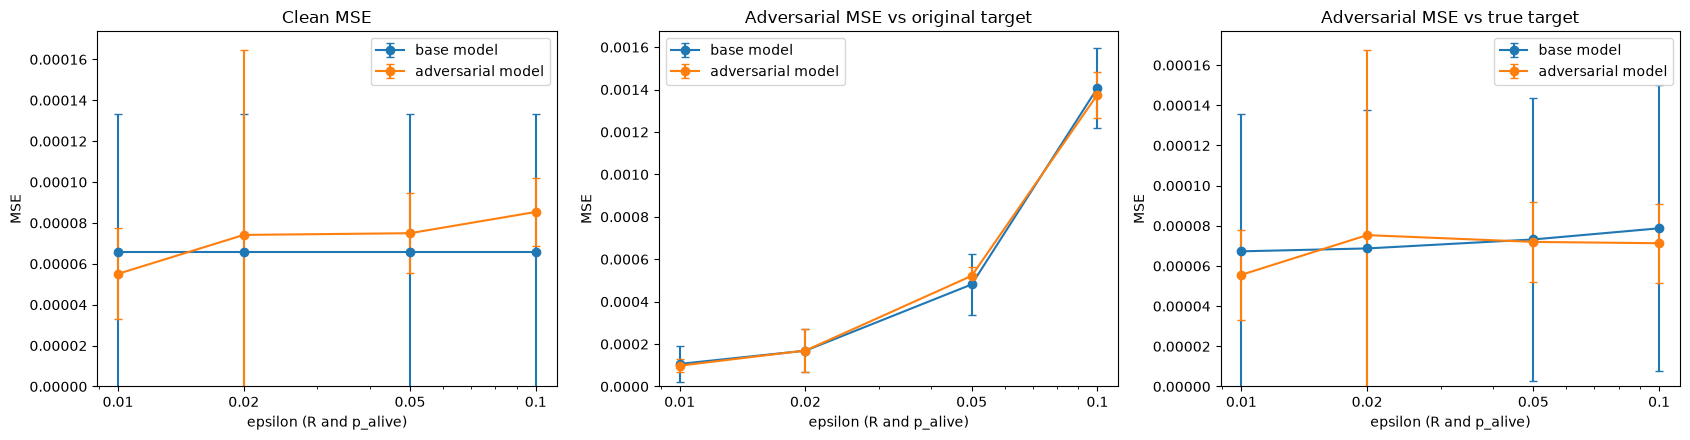

In [21]:
###################################################
### Average over seeds and plot against epsilon ###
###################################################

metrics = [('clean', 'Clean MSE'),
           ('adv_original', 'Adversarial MSE vs original target'),
           ('adv_true', 'Adversarial MSE vs true target')]

def summarise(kind, metric):
    values = np.array([[r[metric] for r in results[kind][e]] for e in epsilons])
    return values.mean(axis=1), values.std(axis=1)

# Table: mean +/- std over seeds
print(f"{'epsilon':>8} {'model':>6}" + ''.join(f'{title:>40}' for _, title in metrics))
for i, e in enumerate(epsilons):
    for kind in ['base', 'adv']:
        cells = [summarise(kind, m) for m, _ in metrics]
        print(f'{e:8.2f} {kind:>6}' + ''.join(f'{mean[i]:>27.6f} +/- {std[i]:.6f}' for mean, std in cells))

# Plot: one panel per error, base vs adversarial model
plt.figure(figsize=(17, 4.5))
for j, (metric, title) in enumerate(metrics):
    plt.subplot(1, 3, j + 1)
    for kind, label in [('base', 'base model'), ('adv', 'adversarial model')]:
        mean, std = summarise(kind, metric)
        plt.errorbar(epsilons, mean, yerr=std, marker='o', capsize=3, label=label)
    plt.xscale('log')
    plt.ylim(bottom=0)
    plt.xticks(epsilons, [str(e) for e in epsilons])
    plt.xlabel('epsilon (R and p_alive)')
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
plt.tight_layout()
plt.show()

***
# **FROM PGD TO PROPERTIES**

**Ethics is not MNIST.** In MNIST the label is the same everywhere inside the epsilon-ball, so any
change in the output is an error, and PGD measures exactly that. Here the correct effort *moves*
with `R` and `p_alive`: an agent that is more at risk, or a room whose children are less likely to
be alive, should get a different effort. Compare the two adversarial panels above. Against the
original target the error grows with epsilon, but most of it is the controller's own slope. Against
the true target at x', the base network is still close to the controller, so PGD is mostly measuring
how the world changes, not a flaw of the network.

**Adversarial training therefore asks for the wrong thing.** Keeping the original target at x' asks
the network to be flat where the world is not. The clean-MSE panel shows what that costs in
accuracy as epsilon grows, and the true-target panel shows whether anything was gained.

**What we want are properties, not invariances.** Instead of "the output must not change inside the
ball", the right question is "does the network's behaviour satisfy a principle for *every* input in a
region?". A property can depend on the input, the way `safeFar` in the drug controller depends on the
current concentration, so it moves with the world rather than against it. The SaveMe principles
(P1 to P9) are the natural candidates, and they are deliberately *not* part of the controller that
generated the labels, so verifying them tests what the network learned rather than what it was told.

**Principles conflict.** Maximising expected utility, deferring to certainty and avoiding likely
failure pull in different directions, so no single network needs to satisfy all of them. Verifying
each principle separately shows which ones a given network embodies, and the counterexamples show
where and why the others fail. Different networks (base, adversarial, different seeds) can then be
compared by the set of principles they satisfy.

**Property-driven training closes the loop.** As in the drug-verification controller, chosen
properties can be turned into training losses with Vehicle. Which principles to enforce becomes an
explicit, checkable choice, instead of a side-effect of PGD.

Next steps:

1. Specify the principles as Vehicle properties over `[R, p_alive, n_estimated, urgency, is_closed]`.
2. Verify the base and adversarial models against each principle and collect counterexamples.
3. Train with a chosen subset of principles as property losses and compare which principles hold.